## Code for armB pre (July 15th 2025)

In [2]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [3]:

import marsilea as ma
import marsilea.plotter as mp

In [4]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [5]:
## read in data

arm = 'ArmB_2024/'
log_data = 'CN_pre/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) 

In [6]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None)) 
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 

In [7]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(269263, 31)
(269263, 1)
(269263, 2)


In [8]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
[   196      1   1842   1005    313  22160     12  23315    155      7
 100572  30628    725  13703     36    191     77   1043     17     64
  69574    150    290   3187]


In [9]:
cluster_asgn1 = cluster_asgn.flatten()

## scanpy

In [11]:
import scipy 
import os
import scipy.io as sio
import scanpy as sc

In [12]:
df = count_matrix[:,21:26]
adata = sc.AnnData(df)


adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]

adata.obs["louvain"] = cluster_asgn1
print(adata.var_names[:10])

Index(['Gene_0', 'Gene_1', 'Gene_2', 'Gene_3', 'Gene_4'], dtype='object')


In [13]:
adata

AnnData object with n_obs × n_vars = 269263 × 5
    obs: 'louvain'

In [14]:
y_marker = ['FoxP3','CD3',  'CD8', 'PD1','PDL1' ]
cell_markers = {
    "T reg cells": ["FoXP3"],
    "CD3+ T cells": ["CD3"],
    "CD8 T cells": ["CD8"],
    "PD-1 cells": ["PD-1"],
    "PD-L1 cells": ["PD-L1"],
}

cells, markers = [], []
for c, ms in cell_markers.items():
    cells += [c] * len(ms)
    markers += ms

uni_cells = list(cell_markers.keys())
cell_colors = [
    "#568564",
    "#DC6B19",
    "#F72464",
    "#005585",
    "#9876DE",
    "#405559",
    "#58DADA",
    "#F85959",
]
cmapper = dict(zip(uni_cells, cell_colors))

In [15]:
exp = adata[:, 0:5].X.toarray()


In [16]:
agg = sc.get.aggregate(adata[:, 0:5], by="louvain", func=["mean", "count_nonzero"])
agg.obs["cell_counts"] = adata.obs["louvain"].value_counts()
agg

AnnData object with n_obs × n_vars = 24 × 5
    obs: 'louvain', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [17]:
agg_exp = agg.layers["mean"]
agg_count = agg.layers["count_nonzero"]
agg_cell_counts = adata.obs["louvain"].value_counts().to_numpy()

In [18]:
agg_cell_counts

array([100572,  69574,  30628,  23315,  22160,  13703,   3187,   1842,
         1043,   1005,    725,    313,    290,    196,    191,    155,
          150,     77,     64,     36,     17,     12,      7,      1])

In [19]:
adata.obs["louvain"].value_counts()

louvain
11    100572
21     69574
12     30628
8      23315
6      22160
14     13703
24      3187
2       1842
18      1043
3       1005
13       725
5        313
23       290
0        196
16       191
9        155
22       150
17        77
20        64
15        36
19        17
7         12
10         7
1          1
Name: count, dtype: int64

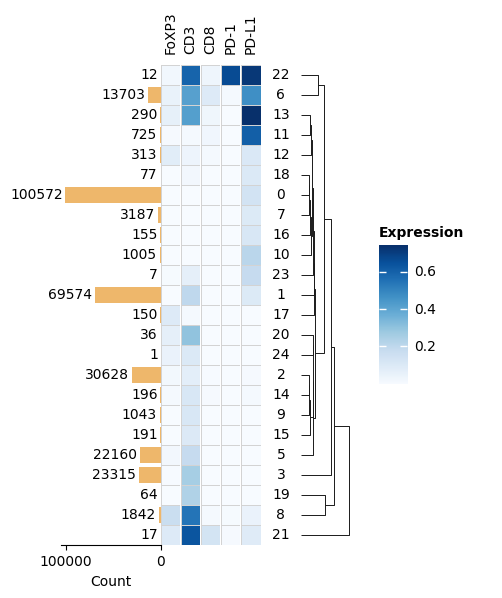

In [20]:
h, w = agg_exp.shape

m = ma.Heatmap(
    agg_exp,
    height=h / 5,
    width=w / 5,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)

m.add_right(mp.Labels(agg.obs["louvain"], align="center"), pad=0.1)
m.add_top(mp.Labels(markers), pad=0.1)

m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.add_left(mp.Numbers(agg_cell_counts, color="#EEB76B", label="Count"))
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

In [19]:
uni_cells

['T reg cells', 'CD3+ T cells', 'CD8 T cells', 'PD-1 cells', 'PD-L1 cells']

### merge clusters


In [22]:
cluster_asgn2 = np.zeros(cluster_asgn1.shape)

In [23]:
#pdl1
row = np.where(cluster_asgn1==18)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==0)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==7)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==16)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==10)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==11)
cluster_asgn2[row]=np.int64(100)


#fox cd3
row = np.where(cluster_asgn1==24)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==20)
cluster_asgn2[row]=np.int64(600)


#cd3
row = np.where(cluster_asgn1==2)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==14)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==9)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==15)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==5)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==3)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==19)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==12)
cluster_asgn2[row]=np.int64(300)

#fox/cd3/pdl1

row = np.where(cluster_asgn1==8)
cluster_asgn2[row]=np.int64(500)
row = np.where(cluster_asgn1==13)
cluster_asgn2[row]=np.int64(500)

#cd3/8/pdl1/fox
row = np.where(cluster_asgn1==21)
cluster_asgn2[row]=np.int64(500)
row = np.where(cluster_asgn1==6)
cluster_asgn2[row]=np.int64(500)


#cd3 pdl1
row = np.where(cluster_asgn1==1)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==23)
cluster_asgn2[row]=np.int64(200)


#fox/pdl1
row = np.where(cluster_asgn1==17)
cluster_asgn2[row]=np.int64(400)

#fox/cd3/pdl1/pd1
row = np.where(cluster_asgn1==22)
cluster_asgn2[row]=np.int64(700)

cluster_asgn2 = np.int64(cluster_asgn2/100)
cluster_asgn2 = cluster_asgn2-1

0
green
1
dimgray
2
orchid
3
darkviolet
4
red
5
orange
6
limegreen


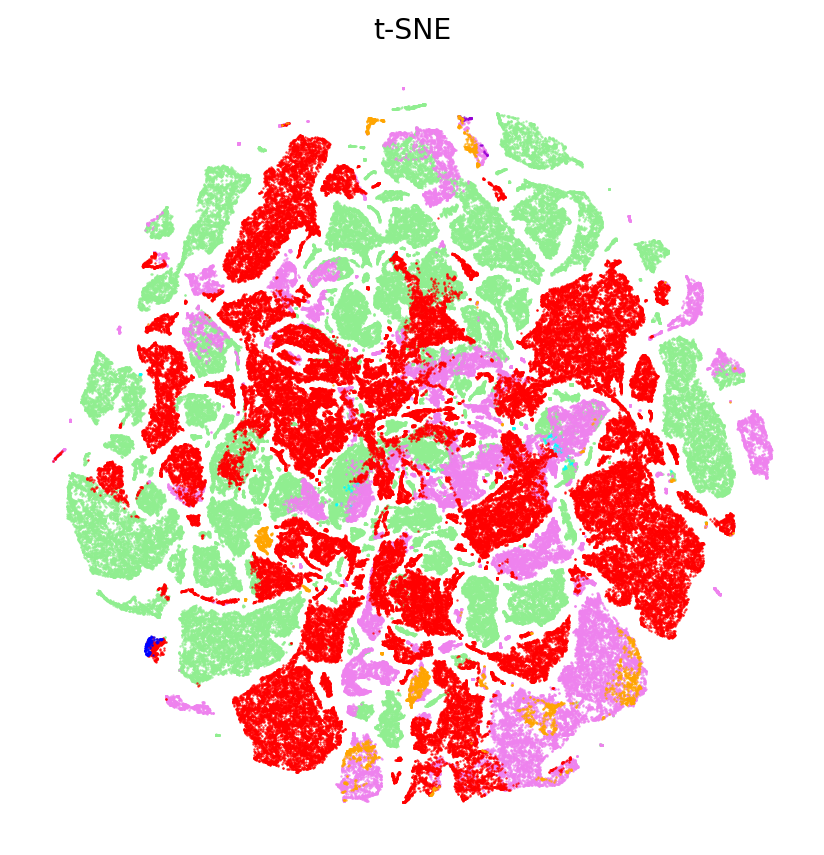

In [25]:

unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
plt.figure(figsize=(6,6),dpi=170)
plt.axis('off')

#colors = ['darkgreen', 'limegreen','lightgreen','royalblue','darkviolet','deeppink']
#colors = ['lightgreen','cyan', 'violet', 'darkviolet', 'red' ,'orange','blue','lightblue']
colors = ['lightgreen','cyan', 'violet', 'darkviolet', 'red' ,'orange','blue']

for i,  label in zip(target_ids,  unique1):
    print(label)
    c=colours_30[i+3] #cm.colors[i]
    print(c)
    plt.scatter(X_2d_1[ cluster_asgn2==(i), 0], X_2d_1[ cluster_asgn2==(i), 1], color=colors[i],label=label,s=1,linewidths=0,alpha=0.8)
#plt.legend(loc=3)
plt.title('t-SNE')
plt.show()


In [26]:
unique_ts, counts_ts = np.unique(count_matrix[:,19], return_counts=True)
print(unique_ts)

[0. 1. 2.]


In [27]:
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
cell_classes = ['PD-L1+','CD3+ PD-L1+','CD3+','FoxP3+ PD-L1+','FoxP3+ CD3+ CD8+ PD-L1+','FoxP3+ CD3+','FoxP3+ CD3+ PD-1+ PD-L1+']

listOfStrings = [" "] * 269263
col_len = []
for i,  label in zip(target_ids,  unique1):
    print(label)
    s= np.array(np.where(cluster_asgn2==label)).flatten()
    print(s.shape)
    print(s)
    col_len.append(np.int64(s.shape))
    
    
    for j in range(len(s)):
        listOfStrings[s[j]]=cell_classes[label]
    

0
(102021,)
[     0      1      2 ... 266647 266659 266661]
1
(291,)
[ 29583  37954  37969  38010  38340  38481  38490  38722  38723  38737
  38744  38753  38762  38765  38769  38777  38781  38800  38919  38921
  38929  39068  39207  39218  39338  60853  62004  62961  62969  62985
  63690  63718  63726  63740  63785  64560  64561  64564  64565  64841
  73675  76851  76888  76897  76906  76930  76941  77002  77423  77436
  77439  77478  77551  77927  77933  77941  78118  78605  78615  78632
  79932  79959  80081  80211  80221  80860  81008  82714 124884 125744
 125749 126225 130373 130374 130797 131161 131803 138627 152031 153574
 156555 156556 156696 156910 156954 156972 156985 156990 156997 157118
 157135 157674 159793 161218 161836 161951 161995 162002 162141 162258
 162272 162277 162302 162352 162357 162380 162397 162401 162446 162519
 162520 162538 162555 162973 163382 163429 163520 163529 165595 165599
 165644 165646 165694 165696 165697 165698 165700 165702 168580 168660
 168675 

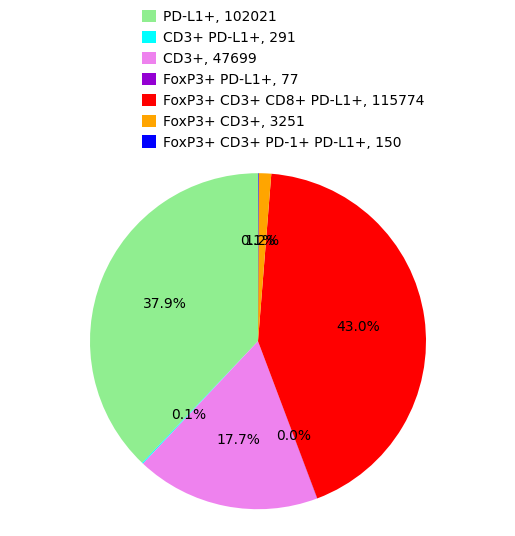

In [28]:
import matplotlib.pyplot as plt
cell_classes = ['PD-L1+','CD3+ PD-L1+','CD3+','FoxP3+ PD-L1+','FoxP3+ CD3+ CD8+ PD-L1+','FoxP3+ CD3+','FoxP3+ CD3+ PD-1+ PD-L1+']

labels = cell_classes#['dogs','cats','birds','fish']
sizes = np.array(col_len).flatten() #[34, 24,18,13]
#c= ["green","dimgray","orchid","darkviolet",
#              "red", "orange"]
pie = plt.pie(sizes,autopct='%1.1f%%', startangle=90, colors=colors)
plt.axis('equal')
plt.legend( loc = 'right', labels=labels)

labels = [f'{l}, {s:0.0f}' for l, s in zip(labels, sizes)]
plt.legend(bbox_to_anchor=(0.85, 1), loc=4, labels=labels)


plt.show()